# GMM-CT: Reconstructing Moving Objects from their X-ray Projections
## Motion-enabled tomography via Gaussian mixture models
#### *Daniel Burrows, March 2026*

#### In this notebook we will discuss and run an algorithm I have developed that accurately reconstructs GMMs that are X-rayed while in rotational and projectile motion.

#### We will walk through this in a way that mimics the process that would be taken in practice; namely:
#### 1. **Data:** Observing the CT data of the GMM we wish to reconstruct.
#### 2. **Spatio-temporal model:** Constructing the spatio-temporal model of a GMM prediction.
#### 3. **Forward model:** Stating the image of the GMM under the ray transform.
#### 4. **The Inverse problem:** Fundamentally, what are we trying to solve.
#### 4. **Optimisation algorithm (trajectory):** Recovering the trajectories of the individual Gaussians.

## 1. Data

#### Consider a two-dimensional application, meaning the objects we wish to recover are two-dimensional and therefore have a one-dimensional sinogram (i.e. projection data).

#### We assume there is a single fixed source $\mathbf{s}_0\in\mathbb{R}^2$ and $N_r$ receivers $\{\mathbf{r}_j\}_{j=1}^{N_r}$ located opposite $\mathbf{s}_0$. The locations of the source and receivers are known.

#### Lastly, denote the time series of the projection data by $g_k(\mathbf{r}_j)$ for $k=1, \ldots, N_t$, where $t_1 < t_2 < \ldots < t_{N_t}$ are the acquisition times.

In [1]:
from pathlib import Path

from gmm_ct.config.yaml_config import load_simulate_config, load_reconstruct_config
from gmm_ct.simulation import run_simulation
from gmm_ct.reconstruct import _load_projection_data
from gmm_ct.core.forward_model import ForwardModelMixin
from gmm_ct.core.initialization import InitializationMixin
from gmm_ct.core.reconstruction import GMM_reco
from gmm_ct.visualization.animations import animate_GMM_motion, save_GMM_animation
from gmm_ct.visualization.publication import animate_temporal_gmm_comparison, reorder_theta_to_match_true

import torch
from torchmin import minimize
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from scipy.optimize import linear_sum_assignment

### Simulate and load the projection data

In [2]:
# ---- Simulate ------------
sim_cfg_path = Path("configs/simulate.yaml")
sim_cfg = load_simulate_config(sim_cfg_path)
sim_dir = run_simulation(sim_cfg)


# ---- Load ------------
cfg_path = Path("configs/reconstruct.yaml")
cfg = load_reconstruct_config(cfg_path)
cfg.data_path = sim_dir / 'projections.pt'

# Check for GPU
if cfg.device:
    device = torch.device(cfg.device)
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

proj_data, t = _load_projection_data(cfg.data_path, device)

✓ Parameters successfully exported to Markdown: data/simulated/20260303_133552_seed40_N5/true_parameters.md


### Visualise the GMM we wish to reconstruct

Animation saved as true_gmm_animation.gif


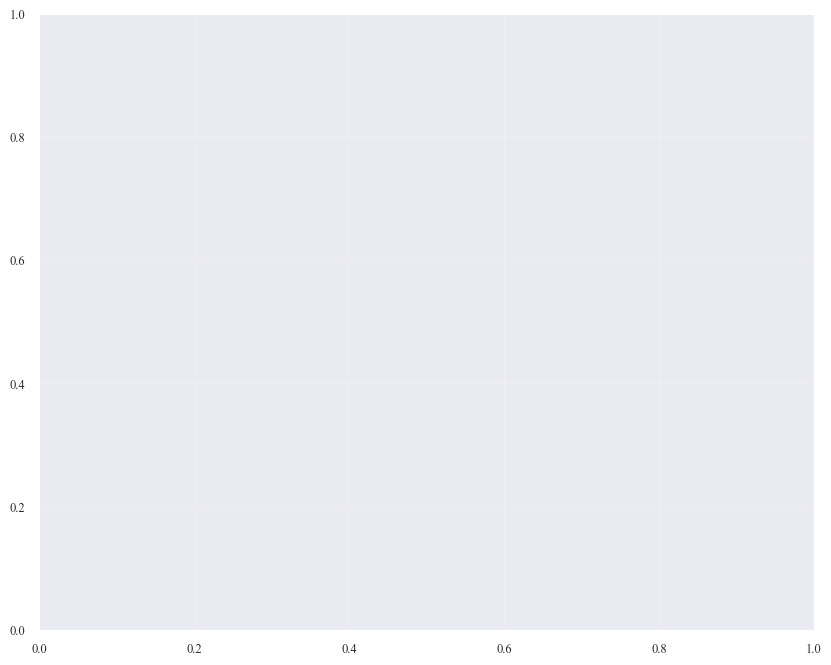

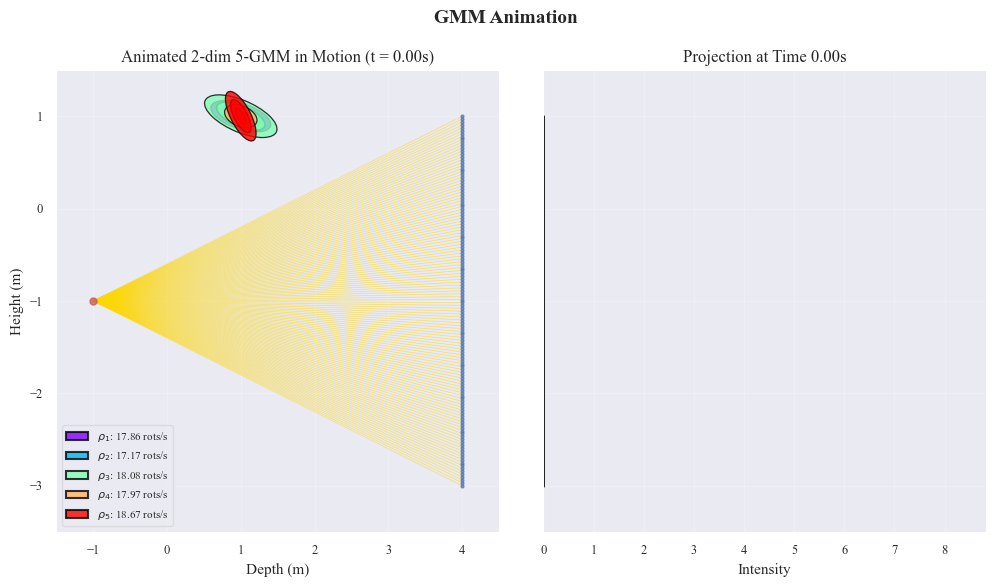

In [3]:
# Load the ground truth data
directory = Path(cfg.data_path).parent
gt_file_path = directory / "ground_truth.pt"
gt_data = torch.load(gt_file_path, map_location=device, weights_only=False)

# Load the true parameters
theta_true = gt_data["theta_true"]
N = cfg.n_gaussians
sources, receivers = cfg.geometry.to_tensors(device)
d = len(*sources)

# Visualise the projection data in time
# plt.ioff()
save_GMM_animation(theta_true, 
                   d=d, 
                   K=N, 
                   sources=sources, 
                   rcvrs=receivers, 
                   t=t, 
                   projs_by_source=[proj_data], 
                   filename='true_gmm_animation.gif', 
                   fps=7)

In [4]:
Image(url='true_gmm_animation.gif')

## 2. Spatio-temporal model

### Morphology

#### We consider anisotropic Gaussian functions with morphology parameterised by $U\in\mathbb{R}^{d\times d}$. 

#### That is, for a GMM comprising of $N$ Gaussians $\rho_n(x)$, we define 
#### $$ \rho_n(x) := \rho_0(U_nx),$$
#### where $\rho_0(x) := e^{-x^Tx}$ for $x\in\mathbb{R}^d$.

### Rotational motion
#### The rotational motion of $\rho_n$ is also described by the action of a matrix, namely $R_{\omega_n}(t)\in\textnormal{SO}(d)$.

#### This is applied as
#### $$ \rho_n(x, t) := \rho_n(R_{\omega_n}(t)^\top x)$$

### Projectile motion
#### The projectile motion of $\rho_n$ is applied through spatially translating by the vector-valued function
#### $$ \mathbf{C}[\mathbf{\eta}_n](t) := \mathbf{\mu} + \mathbf{v}_nt + \tfrac{1}{2}\mathbf{a}t^2. $$

### Spatio-temporal model for a GMM
#### We then obtain the GMM-in-motion model as
#### $$ \sum_{n=1}^N\alpha_nA[U_n, \mathbf{\eta}_n](t)\rho_0.\tag{1} $$

## 3. Forward model: The ray transform
#### The ray transform of a time-varying function $t\mapsto f(\,\cdot\,, t)$ is 
#### $$ \mathcal{X}(f(\,\cdot\,, t))[\mathbf{s}, \mathbf{r}] := \int_{-\infty}^\infty f(\mathbf{s} + \xi(\widehat{\mathbf{r} - \mathbf{s}}), t)d\xi, \qquad \widehat{\mathbf{x}} := \mathbf{x} / \|\mathbf{x}\|. $$

#### Let $\mathbf{\Gamma}$ denote the vector of all parameters for all Gaussians. It can be shown that the ray transform of (1) is
#### \begin{align*}
    F[\mathbf{\Gamma}](\mathbf{s}, \mathbf{r}, t) &:= \sum_{n=1}^N\alpha_n\mathcal{X}\bigl(A[U_n, \mathbf{\eta}_n](t)\rho_0\bigr)[\mathbf{s}, \mathbf{r}]
    \\
    &= \sum_{n=1}^{N}
    \frac{\sqrt{\pi}\;\alpha_n}{\left\|\tilde{U}_n(t)\,\widehat{r}_{sr}\right\|}
    \exp\!\left(
    \frac{
      \bigl\langle\tilde{U}_n(t)(\mathbf{r} - \mathbf{s}), \tilde{U}_n(t)(\mathbf{s} - \mathbf{C}[\mathbf{\eta}_n](t))\bigr\rangle^2
    }{
      \left\|\tilde{U}_n(t)(\mathbf{r} - \mathbf{s})\right\|^2
    }
    - \left\|\tilde{U}_n(t)(\mathbf{s} - \mathbf{C}[\mathbf{\eta}_n](t))\right\|^2\right)\tag{2}\end{align*}
#### where $\tilde{U}_n(t) = U_n R_{\omega_n}(t)^\top$ and $\widehat{r}_{sr} = (r - s)\,/\,\|r - s\|$.

## 4. The inverse problem
#### Compute the solution to
#### $$\mathbf{\Gamma}^* = \arg \min_{\mathbf{\Gamma}}L\Bigl(g_k(r_j),\ F[\mathbf{\Gamma}](\mathbf{s}_0, \mathbf{r}_j, t_k)\Bigr)\quad\textnormal{for } j=1, \ldots, N_r,\ k=1, \ldots, N_t\tag{3}$$
#### for a suitably chosen loss function.

#### We decouple (2) into the two sub-inverse problems:
#### \begin{align}
    \mathbf{\Gamma}_P^* &:= \arg \min_{\mathbf{\Gamma}_P}L_P\Bigl(g_k(r_j), F[\mathbf{\Gamma}_P, \mathbf{\Gamma}_M](\mathbf{s}_0, \mathbf{r}_j, t_k) \Bigr),\tag{4}
    \\
    \mathbf{\Gamma}_M^* &:= \arg \min_{\mathbf{\Gamma}_M}L_M\Bigl(g_k(r_j), F[\mathbf{\Gamma}_P^*, \mathbf{\Gamma}_M](\mathbf{s}_0, \mathbf{r}_j, t_k) \Bigr), \quad\textnormal{for } j=1, \ldots, N_r,\ k=1, \ldots, N_t.\tag{5} 
\end{align}
#### where
#### * $\mathbf{\Gamma}_P$ are the projectile motion parameters for the GMM,
#### * $\mathbf{\Gamma}_M$ are the rotational and morphological parameters for the GMM,
#### * $L_P$ and $L_M$ are task-specific loss functions to be determined.

## 5. Optimisation algorithm: Trajectory recovery

#### A natural initial choice of loss function in (3) is the sum of the $L^2$ error between projections at each time
#### $$
    L_P\Bigl(g_k(r_j), F[\mathbf{\Gamma}_P, \mathbf{\Gamma}_M](\mathbf{s}_0, \mathbf{r}_j, t_k) \Bigr) := \sum_{k=1}^{N_t}\Bigl\|g_k - F[\mathbf{\Gamma}](\mathbf{s}_0, \mathbf{r}_j, t_k)\Bigr\|_{L^2}.
$$
#### However, this loss function struggles to locate the global minimum:

In [5]:
class InitClassWrapper(InitializationMixin):
    def __init__(self, N, device, d, receivers, x0s, a0s, omega_min=16.0, omega_max=24.0):
        self.N = N
        self.device = device
        self.d = d
        self.receivers = receivers
        self.omega_min = omega_min
        self.omega_max = omega_max

        self.n_rcvrs = len(receivers[0])
        self.x0s = x0s
        self.a0s = a0s

class FMClassWrapper(ForwardModelMixin):
    def __init__(self, N, device, d, sources, receivers, x0s, a0s, omega_min=16.0, omega_max=24.0):
        self.N = N
        self.device = device
        self.d = d
        self.sources = sources
        self.receivers = receivers
        self.omega_min = omega_min
        self.omega_max = omega_max

        self.n_sources = len(sources)
        self.n_rcvrs = len(receivers[0])
        self.x0s = x0s
        self.a0s = a0s

        self.sqrt_pi = torch.sqrt(torch.tensor(torch.pi))

        self.theta_fixed = {'x0s': [x0.clone() for x0 in theta_pred_dict['x0s']],
                            'a0s': [a0.clone() for a0 in theta_pred_dict['a0s']], 
                            'U_skews': [U_k.clone() for U_k in theta_pred_dict['U_skews']], 
                            'omegas': [omega.clone() for omega in theta_pred_dict['omegas']], 
                            'alphas': [alpha.clone() for alpha in theta_pred_dict['alphas']]}

In [6]:
# Initialise the estimate
ICW = InitClassWrapper(N, device, d, receivers, theta_true['x0s'], theta_true['a0s'])
init_params_dict = ICW.initialize_parameters(t, proj_data)
theta_pred_dict = init_params_dict.copy()

def convert_dict_to_tensor(theta_dict):
    """Optimizer requires conversion to a tensor data type"""
    tensor_rows = []
    for n in range(N):
        v0_n = theta_dict['v0s'][n]
        log_v0_n_0 = torch.log(torch.abs(v0_n[0])) # This is what the optimiser "thinks" it is optimising on
        tensor_rows.append(torch.stack([log_v0_n_0, v0_n[1]]))
    theta_tensor = torch.stack(tensor_rows)
    
    return theta_tensor

def convert_tensor_to_dict(theta_tensor):
    """Forward model requires data in dict format"""
    v0s = []; theta_dict = {}
    for n in range(N):
        v0s.append(torch.stack([torch.exp(theta_tensor[n, 0]), theta_tensor[n, 1]]))
    theta_dict['v0s'] = v0s

    return theta_dict

# Mappings required to run optimiser
FMCW = FMClassWrapper(N, device, d, sources, receivers, theta_true['x0s'], theta_true['a0s'])
mse_loss = torch.nn.MSELoss()
def loss_fn(theta_tensor):
    theta_dict = convert_tensor_to_dict(theta_tensor)

    # Generate the predicted projections
    pred_projs = FMCW.generate_projections(t, theta_dict, loss_type='trajectory')[0]
    return mse_loss(proj_data, pred_projs)


# ---- Optimise ------------
theta_pred_tensor = convert_dict_to_tensor(theta_pred_dict)
res = minimize(fun=loss_fn, 
               x0=theta_pred_tensor, 
               method='l-bfgs')
final_v0_preds = convert_tensor_to_dict(res.x)
theta_pred_dict['v0s'] = final_v0_preds['v0s'].copy()

Saving animation to direct_traj_est.gif...
✓ Animation saved: direct_traj_est.gif


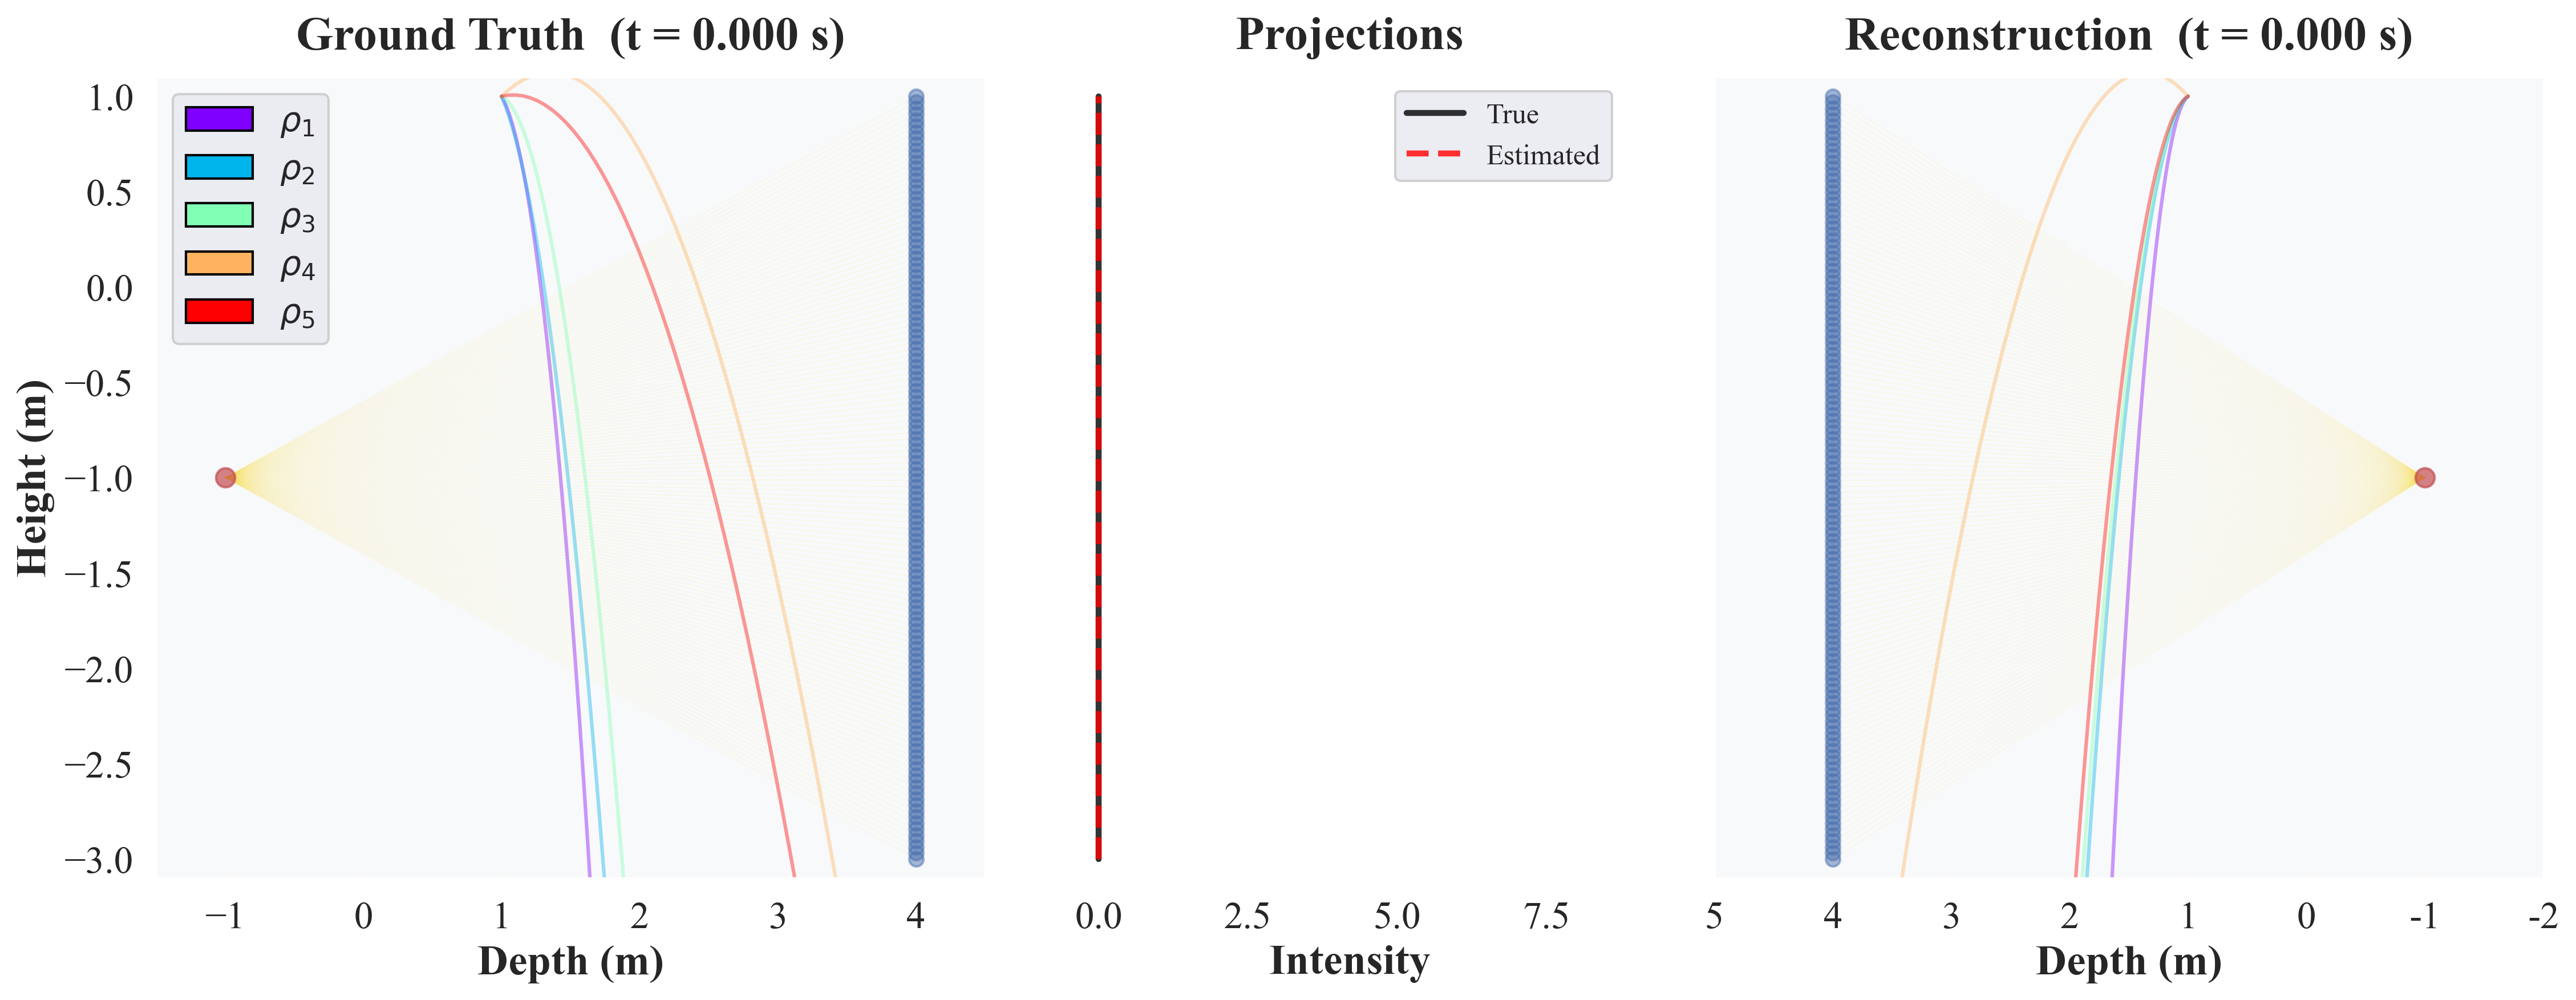

In [7]:
theta_pred_dict, _ = reorder_theta_to_match_true(theta_true, theta_pred_dict, N)
animate_temporal_gmm_comparison(sources, 
                                receivers, 
                                theta_true, 
                                theta_pred_dict, 
                                t, 
                                N, 
                                d,
                                filename='direct_traj_est.gif',
)

In [8]:
Image(url='direct_traj_est.gif')

## Instead, we must take a different approach.

#### At a fixed time $t_k$, we call a receiver $\mathbf{r}_{j, k}$ a _mode_ of the projection $g_k$ if $g_k(\mathbf{r}_{j, k})$ is a local maximum of $g_k$.

#### In two dimensions, we can compute these from each $g_k$ by computing
#### $$
    \mathcal{DM}(g_k) := \{\mathbf{r}_j : g_k(\mathbf{r}_{j-1}) < g_k(\mathbf{r}_j) > g_k(\mathbf{r}_{j+1})\} \tag*{($\mathcal{DM} = $ "Data modes")}
$$

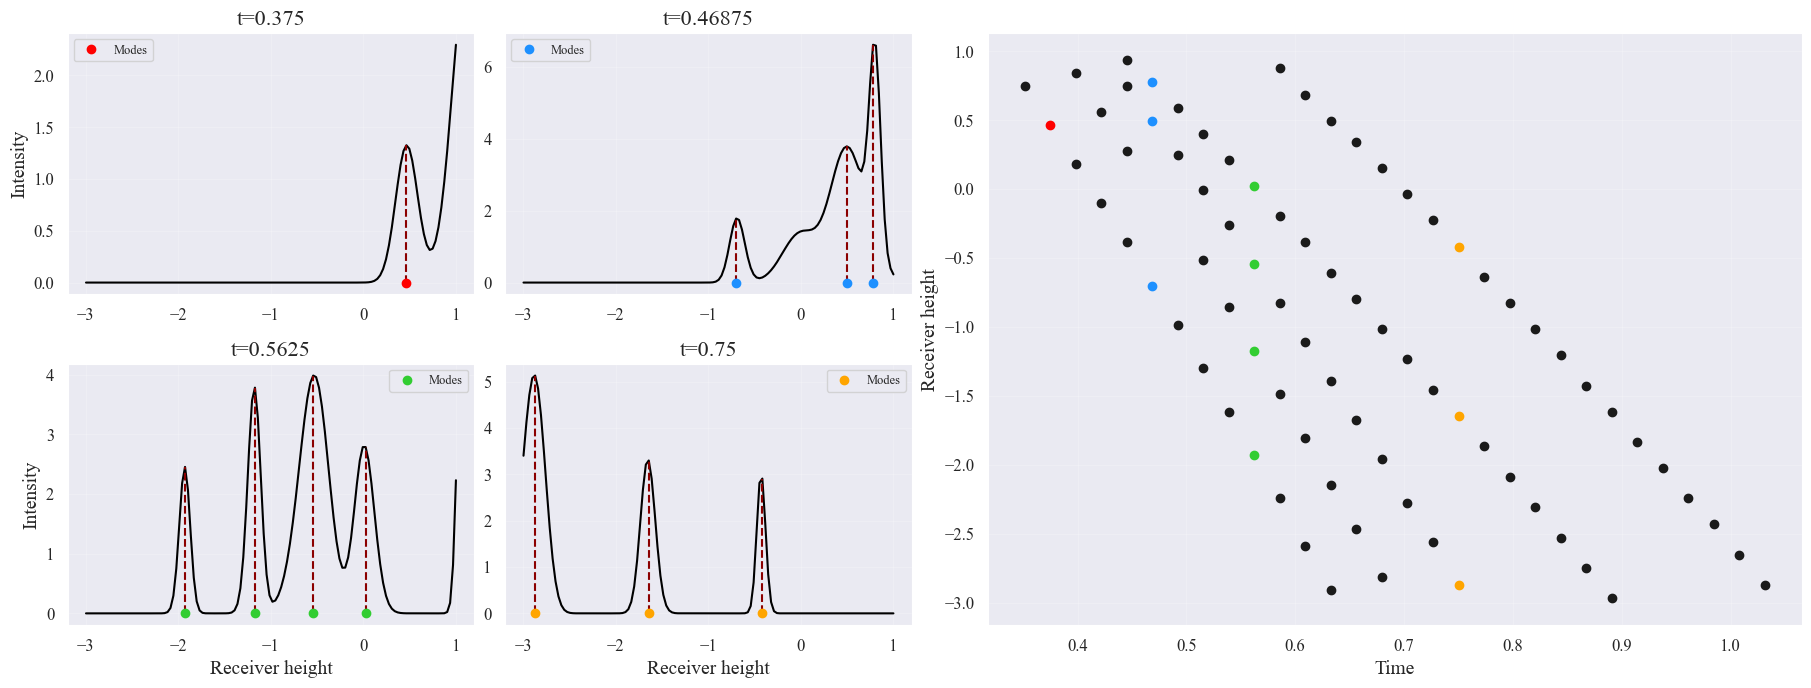

In [9]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 12), layout='constrained')

gs = GridSpec(4, 4, figure=fig)
gs0 = gs[0, 0]
gs1 = gs[0, 1]
gs2 = gs[1, 0]
gs3 = gs[1, 1]
gs4 = gs[0:2, 2:]

receiver_heights = np.array([r[1] for r in receivers[0]])
time_sample_inds = [16, 20, 24, 32]
g0 = proj_data[time_sample_inds[0]]
g1 = proj_data[time_sample_inds[1]]
g2 = proj_data[time_sample_inds[2]]
g3 = proj_data[time_sample_inds[3]]

def detect_peaks_and_modes(sampled_projs):
    N_plot_samples = len(sampled_projs)
    peaks_list = [[] for _ in range(N_plot_samples)]
    modes_list = [[] for _ in range(N_plot_samples)]
    for n_g, g in enumerate(sampled_projs):
        for j in range(1, len(g) - 1):
            gj_minus_1 = g[j - 1]
            gj = g[j]
            gj_plus_1 = g[j + 1]

            # Test for peak
            if gj_minus_1 < gj and gj > gj_plus_1:
                peaks_list[n_g].append(gj)
                modes_list[n_g].append(receiver_heights[j])
    
    return peaks_list, modes_list
        
peaks_list, modes_list = detect_peaks_and_modes([g0, g1, g2, g3])
g0_modes, g0_peaks = modes_list[0], peaks_list[0]

ax0 = fig.add_subplot(gs0)
ax1 = fig.add_subplot(gs1)
ax2 = fig.add_subplot(gs2)
ax3 = fig.add_subplot(gs3)
ax4 = fig.add_subplot(gs4)

axs = [ax0, ax1, ax2, ax3]

ax0.plot(receiver_heights, g0, color='black')
ax1.plot(receiver_heights, g1, color='black')
ax2.plot(receiver_heights, g2, color='black')
ax3.plot(receiver_heights, g3, color='black')
colors = ['red', 'dodgerblue', 'limegreen', 'orange', 'salmon']
for n_g in range(len(axs)):
    ax = axs[n_g]    
    modes, peaks = modes_list[n_g], peaks_list[n_g]
    ax.vlines(modes, 0, peaks, color='darkred', linestyle='--')
    ax.plot(modes, np.zeros(len(modes)), color=colors[n_g], marker='o', lw=0, label='Modes')
    ax.set_title(f"t={t[time_sample_inds[n_g]]}", fontsize=16)
    ax.legend()
    if n_g > 1:
        ax.set_xlabel('Receiver height', fontsize=14)
    if n_g % 2 == 0:
        ax.set_ylabel('Intensity', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

color_counter = 0
data_peaks, data_modes = detect_peaks_and_modes(proj_data)
for n_t, t_k in enumerate(t):
    n_modes = len(data_modes[n_t])
    if n_t not in time_sample_inds:
        ax4.plot(t_k * torch.ones(n_modes), np.array(data_modes[n_t]), marker='o', lw=0, color='k')
    else:
        ax4.plot(t_k * torch.ones(n_modes), np.array(data_modes[n_t]), marker='o', lw=0, color=colors[color_counter])
        color_counter += 1
ax4.tick_params(axis='both', labelsize=12)
ax4.set_xlabel('Time', fontsize=14)
ax4.set_ylabel('Receiver height', fontsize=14)

plt.show()

#### Therefore, at each $t_k$, $\mathcal{DM}(g_k)$ provides the data by which we could fit to.

#### However, to fit trajectory predictions, we also need an explicit, smooth prediction map from trajectory prediction space into mode space. 

#### In other words, for each $n$, we seek the sets
#### $$
    \mathcal{PM}(\mathbf{\eta}_n) := \{\mathbf{r}[\mathbf{\eta}_n](t_k):\mathbf{r}[\mathbf{\eta}_n](t_k)\textnormal{ maximises } \mathbf{r}\mapsto\alpha_n\mathcal{X}\bigl(A[U_n, \mathbf{\eta}_n](t_k)\rho_0\bigr)[\mathbf{s}, \mathbf{r}],\ k=1, \ldots, N_t\}. \tag*{($\mathcal{PM} = $ "Predicted modes")}
$$

#### We can compute these by performing some vector calculus to show that
#### $$
    \mathbf{r}[\mathbf{\eta}_n](t_k)\in\mathcal{PM}(\mathbf{\eta}_n) \iff \mathbf{r}[\mathbf{\eta}_n](t_k) = \mathbf{s}_0 + \dfrac{\mathbf{r}_j^{(0)} - \mathbf{s}_0^{(0)}}{\mathbf{s}_0^{(0)} - \mathbf{C}_n^{(0)}[\mathbf{\eta}_n](t_k)}\bigl(\mathbf{s}_0 - \mathbf{C}[\mathbf{\eta}_n](t_k)\bigr), \qquad k=1, \ldots, N_t, \tag{6}
$$
#### which is the desired trajectory-to-mode smooth map.

## Can we now optimise?

#### Establishing (6) suggests that we could try to set the trajectory loss sub-inverse problem (4) as
#### $$
    L_P\Bigl(g_k(\mathbf{r}_j)_{(j, k)\in\mathbf{\Lambda}}, \ 
    F[\mathbf{\Gamma}_T](\mathbf{s}, \mathbf{r}_j, t_k)_{(j, k)\in\mathbf{\Lambda}}\Bigr) := \sum_{k=1}^{N_t}\sum_{n=1}^{N}\Bigl\|\mathcal{DM}(g_k)_n - \mathbf{r}[\mathbf{\eta}_n](t_k)\Bigr\|_{L_p}.\tag{7}
$$
#### However, this is not an accurate physical model.

#### Instead, at each $t_k$, we compute the optimal assignment of the data modes to the theoretical modes using the Hungarian algorithm.

#### This is the assignment given by
#### $$
    \varphi_k^* = \arg \min_{\varphi_k\in\mathbf{\Phi}_k}\sum_{s=1}^{N_k}\Bigl\|\mathcal{DM}(g_k)_{\varphi_k(s)} - \mathbf{r}[\mathbf{\eta}_n](t_k)\Bigr\|_{L_p},
$$
#### where
#### * $N_k = |\mathcal{DM}(g_k)|$; i.e. the number of observed modes at $t_k$;
#### * $\mathbf{\Phi}_k$ is the set of all injective mappings from $\{1, \ldots, N_k\}$ into $\{1, \ldots, N\}$.

#### Our trajectory loss function is then given by switching $\mathcal{DM}(g_k)_n$ for $\mathcal{DM}(g_k)_{\varphi_k^*(n)}$ in (7).

In [10]:
def traj_to_mode_map(theta_dict):
    all_modes = []
    s0 = sources[0]
    r0 = receivers[0][0]
    EPS = 1e-10
    
    for n in range(N):
        v0_n = theta_dict['v0s'][n]
        x0_n = FMCW.theta_fixed['x0s'][n]
        a0_n = FMCW.theta_fixed['a0s'][n]

        modes_n = []
        for t_k in t:
            C_nk = x0_n + v0_n * t_k + 0.5 * a0_n * t_k**2
            
            numerator = r0[0] - s0[0]
            denominator = s0[0] - C_nk[0]

            denominator_safe = torch.where(
                torch.abs(denominator) < EPS,
                torch.sign(denominator) * EPS + (denominator == 0) * EPS,
                denominator,
            )

            lambda_nk = numerator / denominator_safe

            pred_mode_nk = s0 + lambda_nk * (s0 - C_nk)
            modes_n.append(pred_mode_nk)

        all_modes.append(torch.stack(modes_n))

    return all_modes

def compute_optimal_assignment(data_modes, pred_modes):
    assignments_dict = {}
    for n_t, t_k in enumerate(t):
        if len(data_modes[n_t]) == 0:
            continue
        else:
            dist_matrix = torch.zeros(len(data_modes[n_t]), N)

            for mode_idx, mode in enumerate(data_modes[n_t]):
                for n in range(N):
                    distance = torch.norm(data_modes[n_t][mode_idx] - pred_modes[n][n_t][1], p=2)
                    if torch.isnan(distance) or torch.isinf(distance):
                        dist_matrix[height_idx, gaussian_idx] = 1e10
                    else:
                        dist_matrix[mode_idx, n] = distance.item()

            row_inds, col_inds = linear_sum_assignment(dist_matrix.cpu().numpy())
            assignments_dict[t_k.item()] = [(r, c) for r, c in zip(row_inds, col_inds)] # "data mode m_r assigned to pred mode p_c"
    
    return assignments_dict

def traj_loss_fn(theta_tensor):
    theta_dict = convert_tensor_to_dict(theta_tensor)

    # Make the predictions
    pred_modes = traj_to_mode_map(theta_dict)

    # Compute the optimal assignments for all t_k
    assignments_dict = compute_optimal_assignment(data_modes, pred_modes)

    # Compute the loss
    loss_val = torch.tensor(0.0)
    for n_t, t_k in enumerate(t):
        if t_k.item() not in assignments_dict:
            continue
        else:
            for (data_idx, pred_idx) in assignments_dict[t_k.item()]:
                loss_val += torch.norm(torch.tensor(data_modes[n_t][data_idx]) - pred_modes[pred_idx][n_t][1], p=2)
    return loss_val


### Fit using the best of a collection attempts

In [11]:
records_dict = {}; results = []
N_attempts = 5
for attempt in range(N_attempts):
    print(f"Running attempt {attempt} of {N_attempts+1}")
    
    init_params_dict = ICW.initialize_parameters(t, proj_data)
    theta_pred_tensor = convert_dict_to_tensor(init_params_dict)
    theta_pred_dict = init_params_dict.copy()

    res = minimize(fun=traj_loss_fn, 
                   x0=theta_pred_tensor, 
                   method='l-bfgs')

    records_dict[attempt] = res.fun
    results.append(res.x)

# Save the best fit
best_record = torch.argmin(torch.tensor(list(records_dict.values())))
best_result = results[best_record]

# Update the parameter estimate
final_v0_preds = convert_tensor_to_dict(best_result)
theta_pred_dict['v0s'] = final_v0_preds['v0s'].copy()

Running attempt 0 of 6
Running attempt 1 of 6
Running attempt 2 of 6
Running attempt 3 of 6
Running attempt 4 of 6


### Plot the results

Text(0, 0.5, 'Receiver height')

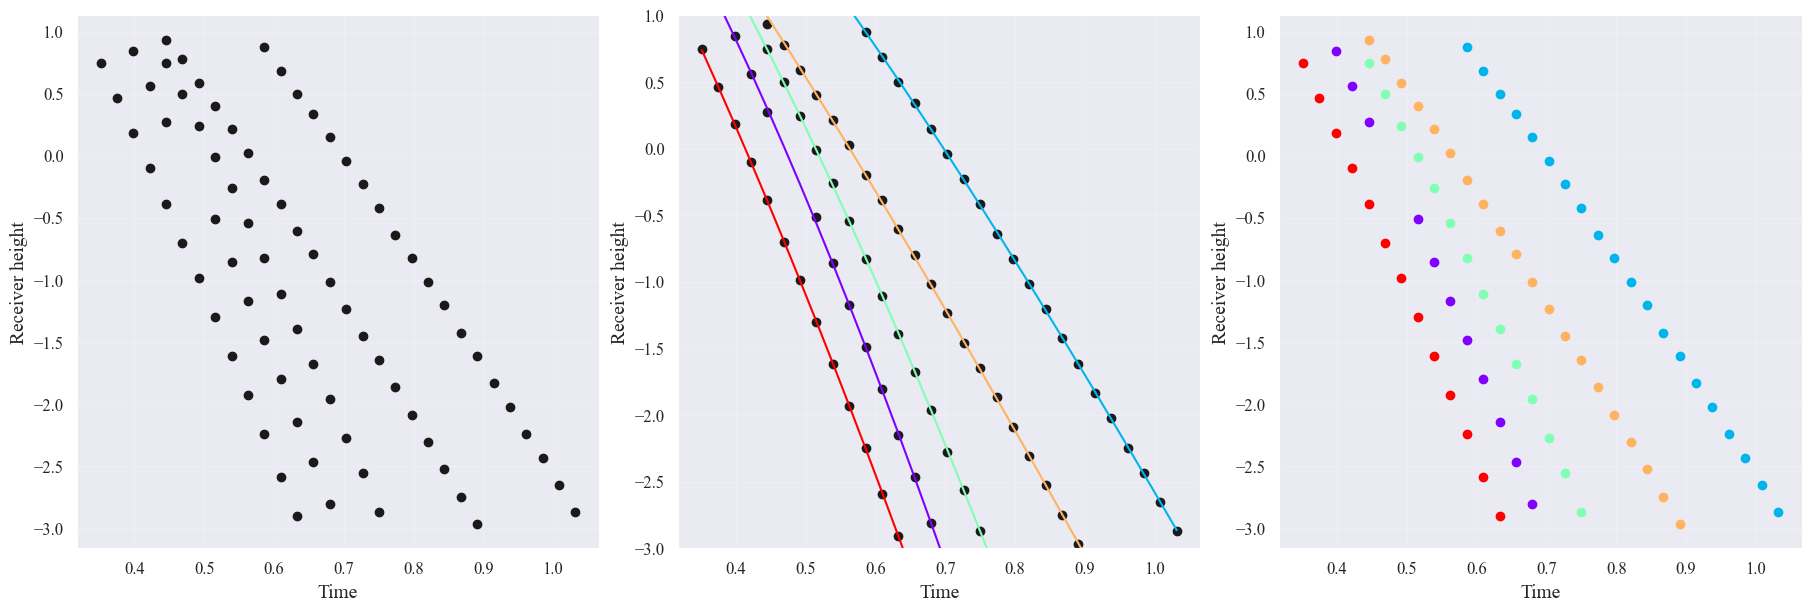

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(18, 6), layout='constrained')
for n_t, t_k in enumerate(t):
    n_modes = len(data_modes[n_t])
    ax1.plot(t_k * torch.ones(n_modes), np.array(data_modes[n_t]), marker='o', lw=0, color='k')
    ax2.plot(t_k * torch.ones(n_modes), np.array(data_modes[n_t]), marker='o', lw=0, color='k')

rainbow_colors = plt.cm.rainbow(np.linspace(0, 1, N))
x0_n = FMCW.theta_fixed['x0s'][0]
a0_n = FMCW.theta_fixed['a0s'][0]
all_modes = traj_to_mode_map(theta_pred_dict)
t_sample = [[] for _ in range(N)]
mode_sample = [[] for _ in range(N)]
for n in range(N):
    for n_t, t_k in enumerate(t):
        if len(data_modes[n_t]) == 0:
            continue
        else:
            t_sample[n].append(t_k)
            mode_sample[n].append(all_modes[n][n_t][1])

for n in range(N):
    ax2.plot(t_sample[n], mode_sample[n], color=rainbow_colors[n])
ax2.set(ylim=(-3, 1))

curves = [[] for _ in range(N)]
for n, ms in enumerate(mode_sample):
    curves[n] = torch.tensor(ms)
assigned_to_curve = [[] for _ in range(N)]
t_count = 0
for n_t, t_k in enumerate(t):
    if len(data_modes[n_t]) == 0:
        continue
    else:
        for dm in data_modes[n_t]:
            dists = torch.tensor([torch.norm(curves[n][t_count] - torch.tensor(dm), p=2) for n in range(N)])
            assignment = torch.argmin(dists)
            assigned_to_curve[assignment].append((t_k, dm))
        t_count += 1

for n in range(N):
    times = [pair[0] for pair in assigned_to_curve[n]]
    vals = [pair[1] for pair in assigned_to_curve[n]]
    ax3.plot(times, vals, color=rainbow_colors[n], marker='o', lw=0)

ax1.tick_params(axis='both', labelsize=12)
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Receiver height', fontsize=14)

ax2.tick_params(axis='both', labelsize=12)
ax2.set_xlabel('Time', fontsize=14)
ax2.set_ylabel('Receiver height', fontsize=14)

ax3.tick_params(axis='both', labelsize=12)
ax3.set_xlabel('Time', fontsize=14)
ax3.set_ylabel('Receiver height', fontsize=14)

Saving animation to Hungarian_traj_est.gif...
✓ Animation saved: Hungarian_traj_est.gif


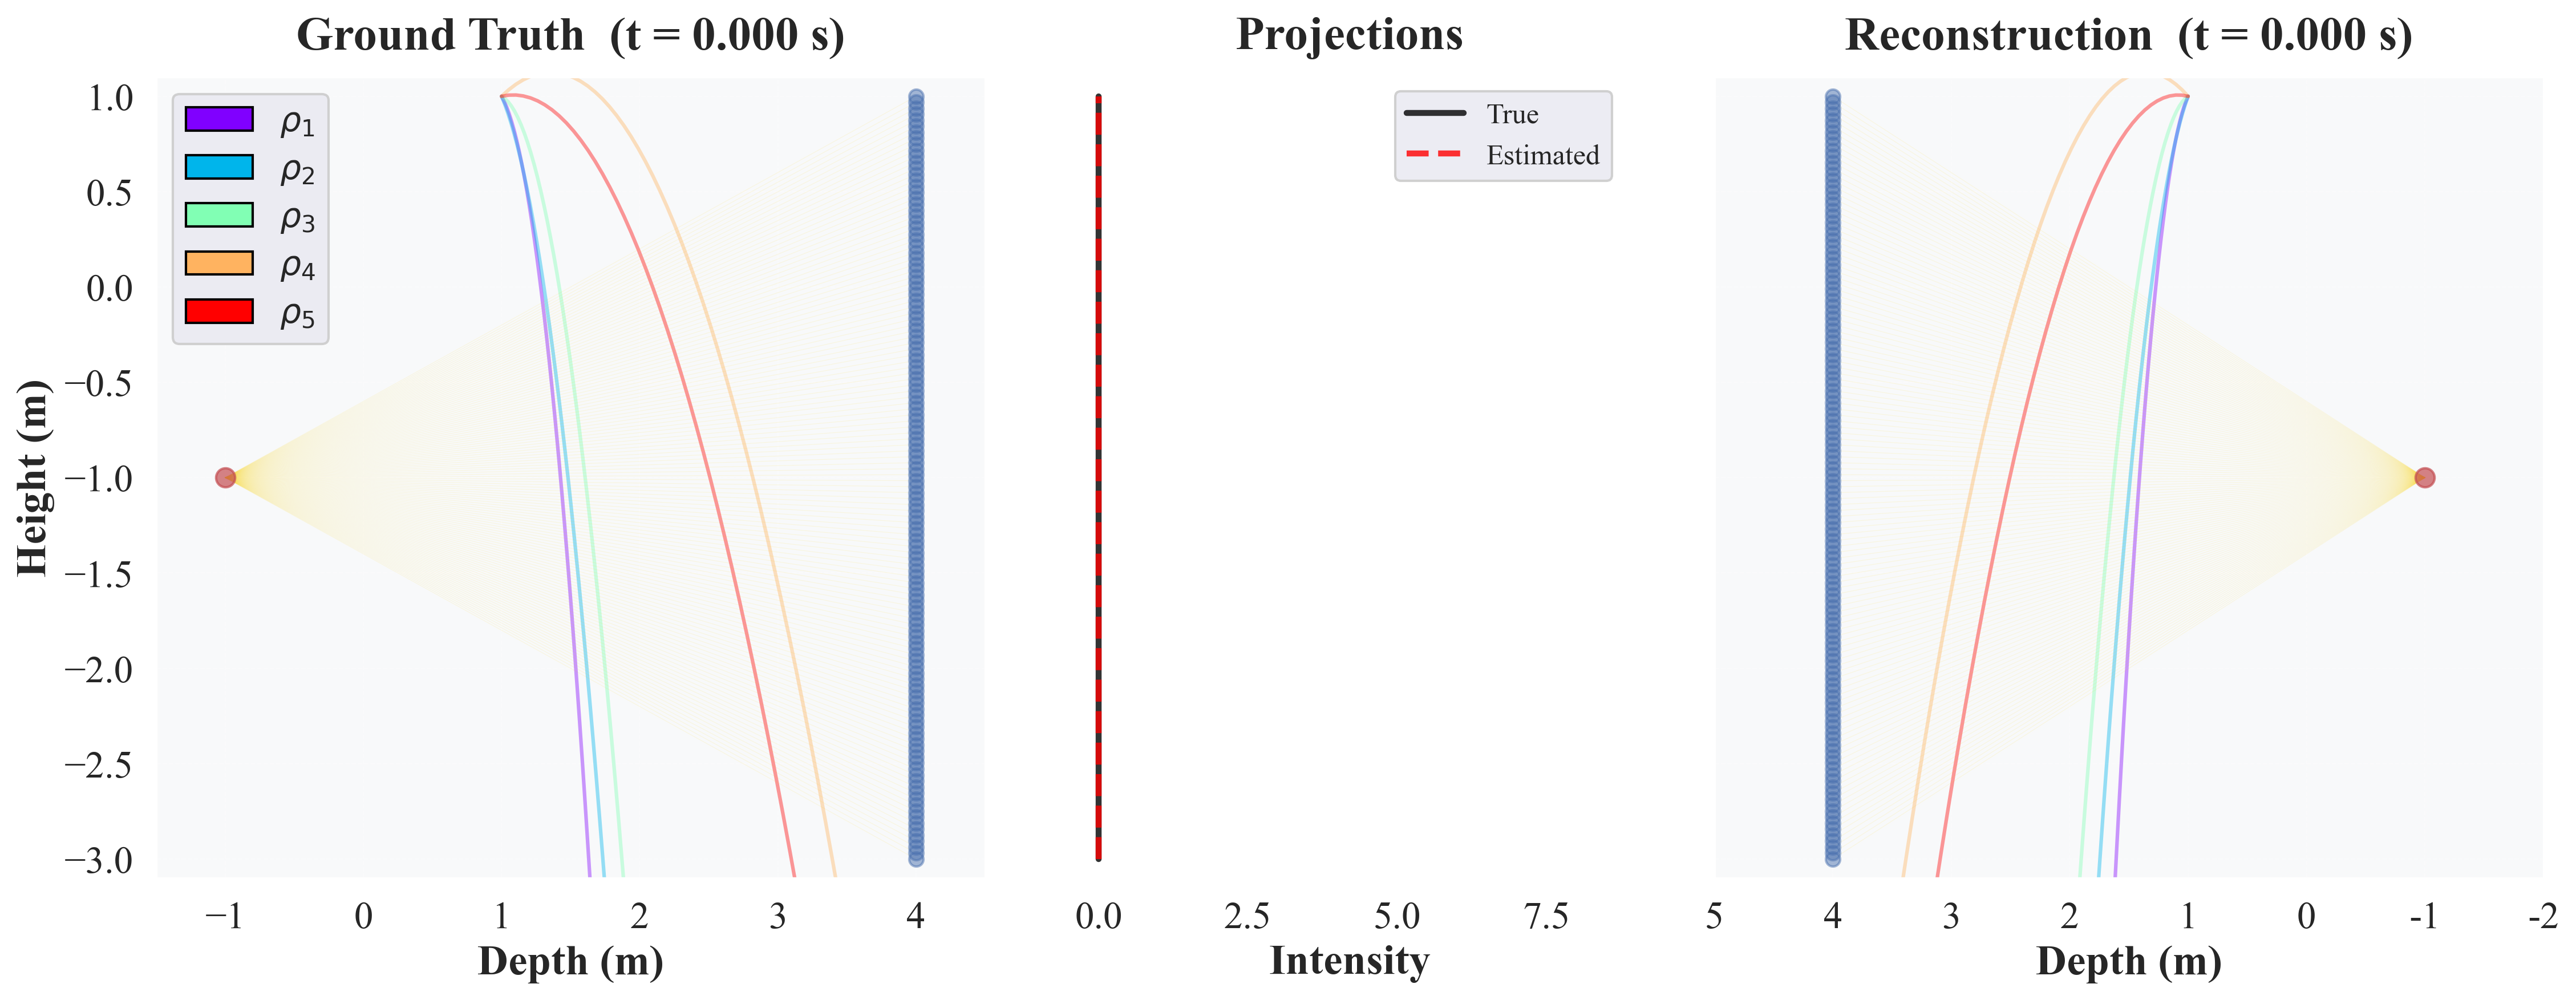

In [13]:
animate_temporal_gmm_comparison(sources, 
                                receivers, 
                                theta_true, 
                                theta_pred_dict, 
                                t, 
                                N, 
                                d,
                                filename='Hungarian_traj_est.gif',
)

In [14]:
Image(url='Hungarian_traj_est.gif')

## We can now optimise for the rest...

In [ ]:
n_omega_inits = 1
gmm_reco = GMM_reco(d=d,
                    N=N,
                    sources=sources,
                    receivers=receivers,
                    x0s=theta_true['x0s'], 
                    a0s=theta_true['a0s'],
                    omega_min=16.0, 
                    omega_max=24.0, 
                    n_omega_inits=n_omega_inits, 
                    N_traj_trials=1)
gmm_reco.t = t
gmm_reco.proj_data = gmm_reco.process_projections(gmm_reco._to_device([proj_data]))
_ = gmm_reco._stage_trajectory_optimization(t, proj_data)
soln_dict, best_loss = gmm_reco._stage_multistart_joint(theta_pred_dict)
soln_dict = gmm_reco._fine_grid_search_omega(soln_dict, best_loss, omega_range=3.0, omega_step=0.1)

animate_temporal_gmm_comparison(sources, 
                                receivers, 
                                theta_true, 
                                soln_dict, 
                                t, 
                                N, 
                                d,
                                filename=f"temporal_gmm_comparison_n_inits={n_omega_inits}.gif",
                                fps=4
                               )

In [15]:
Image(url=f'temporal_gmm_comparison_n_inits={n_omega_inits}.gif')

NameError: name 'n_omega_inits' is not defined

In [16]:
Image(url=f'temporal_gmm_comparison_n_inits={15}.gif')